<a href="https://colab.research.google.com/github/amonguscline/ML-Data-analysis/blob/main/projects/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [ ]:
dftrain=pd.read_csv("/content/sample_data/mnist_train_small.csv",header=None,nrows=2000)
dftest=pd.read_csv("/content/sample_data/mnist_test.csv",header=None,nrows=200)

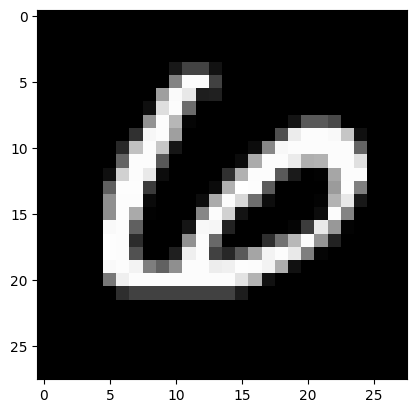

In [ ]:
row=np.array(dftrain.iloc[0,1:])
row=row.reshape(28,28)
plt.imshow(row,cmap='gray')

In [ ]:
Xtrain=dftrain.iloc[:,1:]
ytrain=dftrain.iloc[:,0]
Xtest=dftest.iloc[:,1:]
ytest=dftest.iloc[:,0]

In [ ]:
model=LogisticRegression(max_iter=5000)
model.fit(Xtrain,ytrain)
model.score(Xtest,ytest)

0.9

In [ ]:
model=XGBClassifier(colsample_bylevel=.6,colsample_bynode=.8)
model.fit(Xtrain,ytrain)
model.score(Xtest,ytest)

0.93

In [ ]:
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

In [ ]:
#2=[0,0,1,0,0,0,0,0,0,0] onehot encoding
ytrain=to_categorical(ytrain,num_classes=10)
ytest=to_categorical(ytest,num_classes=10)
Xtrain=Xtrain/255
Xtest=Xtest/255
Xtrain.shape

(2000, 784)

In [ ]:
model = Sequential()
model.add(Dense(256,input_shape=(Xtrain.shape[1],),activation='relu'))
model.add(Dropout(.3))
model.add(Dense(64,activation='relu'))
model.add(Dropout(.4))
model.add(Dense(10,activation='softmax')) #softmax required due to form
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 218,058 (851.79 KB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
esm=EarlyStopping(patience=100)
model.fit(Xtrain,ytrain,epochs=1000,validation_split=.1,callbacks=[esm])
model.evaluate(Xtest,ytest)

Epoch 1/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9985 - loss: 0.0087 - val_accuracy: 0.9300 - val_loss: 0.7299
Epoch 2/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9990 - loss: 0.0017 - val_accuracy: 0.9400 - val_loss: 0.7617
Epoch 3/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9300 - val_loss: 0.9065
Epoch 4/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9985 - loss: 0.0018 - val_accuracy: 0.9250 - val_loss: 1.0378
Epoch 5/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 7.4290e-04 - val_accuracy: 0.9250 - val_loss: 0.9615
Epoch 6/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.9113e-04 - val_accuracy: 0.9250 - val_loss: 0.9913
Epoch 7/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 3.1683e-04 - val_accuracy: 0.9300 - val_loss: 1.1555
Epoch 8/1000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9985 - loss: 0.0031 - val

[0.38861992955207825, 0.9750000238418579]